# TFT Attention & Variable Importance Interpretability

This notebook inspects what the trained Temporal Fusion Transformer
actually attends to and relies on when making forecasts -- distinct from
the SHAP-based feature importance used in the credit-risk project, this
uses TFT's *native* interpretability: its attention weights and learned
variable selection gates, both of which are part of the model's forward
pass rather than a post-hoc explanation technique.

In [1]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import sys
from pathlib import Path

# VS Code's Jupyter interactive window defaults to the notebook's own folder
# as cwd -- switch to the project root so all paths in config.yaml (and
# every src/ script) resolve exactly the same way they do when run normally
# via `python -m src.xxx` from the project root.
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd())

sys.path.append(".")  # so `from src...` imports work

import yaml
import torch
import matplotlib.pyplot as plt

from src.tft_model import load_full_df, build_training_dataset, build_eval_dataset
from pytorch_forecasting import TemporalFusionTransformer

Working directory: c:\projects\Temporal-Fusion-Transformer-Electricity-Forecasting


## Setup: load config, data, and the trained checkpoint

In [2]:
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

full_df, train_df, val_df, test_df = load_full_df(cfg)
training = build_training_dataset(cfg, full_df, train_df)
validation_cutoff = val_df["time_idx"].max()
test_dataset = build_eval_dataset(training, full_df, min_prediction_idx=validation_cutoff + 1)

print(f"Test dataset: {len(test_dataset):,} windows")

Test dataset: 686,090 windows


In [3]:
# Same mtime-based checkpoint selection used in evaluate() -- avoids the
# alphabetical-sort bug that would otherwise pick an earlier, less-trained
# checkpoint over the real one.
ckpts = list(Path("models").glob("tft_best*.ckpt"))
checkpoint_path = str(max(ckpts, key=lambda p: p.stat().st_mtime))
print(f"Loading: {checkpoint_path}")

model = TemporalFusionTransformer.load_from_checkpoint(checkpoint_path)
model.eval()

Loading: models\tft_best-v1.ckpt


c:\Users\Swayam\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Swayam\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\Swayam\AppData\Local\Programs\Python\Python310\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparame

TemporalFusionTransformer(
  	"attention_head_size":               4
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'load_kwh', 'group_ids': ['client_id'], 'weight': None, 'max_encoder_length': 168, 'min_encoder_length': 168, 'min_prediction_idx': 0, 'min_prediction_length': 24, 'max_prediction_length': 24, 'static_categoricals': ['client_id'], 'static_reals': None, 'time_varying_known_categoricals': None, 'time_varying_known_reals': ['hour', 'day_of_week', 'month', 'is_weekend'], 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['load_kwh'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': True, 'lags': None, 'add_relative_time_idx': True, 'add_target_scales': True, 'add_encoder_length': True, 'target_normalizer': GroupNormalizer(
  		method='standard',
  		groups=['client_id'],
  		center=True,
  		scale_by_grou

## Run predictions in "raw" mode

`mode="raw"` returns the full internal output dict (attention weights,
variable selection weights) rather than just the quantile forecast.
Sampling down to a manageable subset -- interpretability analysis doesn't
need the full test set, and computing/storing raw attention tensors for
hundreds of thousands of windows is unnecessary memory pressure for what
this notebook needs.

In [4]:
N_INTERPRET_SAMPLES = 5000

sampler = None
if len(test_dataset) > N_INTERPRET_SAMPLES:
    sampler = torch.utils.data.RandomSampler(
        test_dataset, replacement=False, num_samples=N_INTERPRET_SAMPLES
    )

dataloader = test_dataset.to_dataloader(
    train=False, batch_size=64, num_workers=0, sampler=sampler
)

raw_predictions = model.predict(dataloader, mode="raw", return_x=True, trainer_kwargs={"logger": False})
print("Raw prediction output keys:", list(raw_predictions.output.keys()))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Swayam\AppData\Local\Programs\Python\Python310\lib\site-pac

Raw prediction output keys: ['prediction', 'encoder_attention', 'decoder_attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'decoder_lengths', 'encoder_lengths']


## Aggregate interpretation: what does the model rely on overall?

`interpret_output(reduction="sum")` aggregates attention and variable
selection weights across every sample in this batch, giving a global view
rather than a single-prediction view.

Interpretation components: ['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', 'decoder_length_histogram']
Saved: reports/figures/tft_interpretation_attention.png
Saved: reports/figures/tft_interpretation_static_variables.png
Saved: reports/figures/tft_interpretation_encoder_variables.png
Saved: reports/figures/tft_interpretation_decoder_variables.png


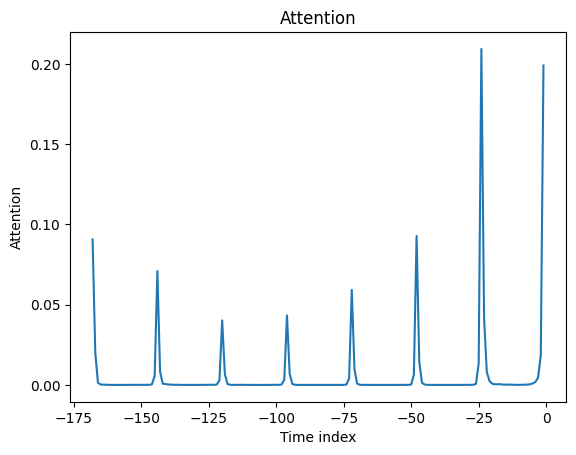

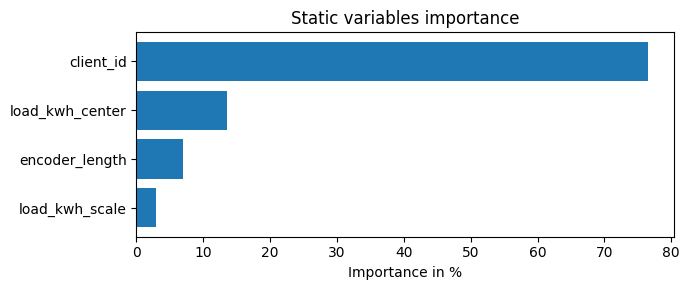

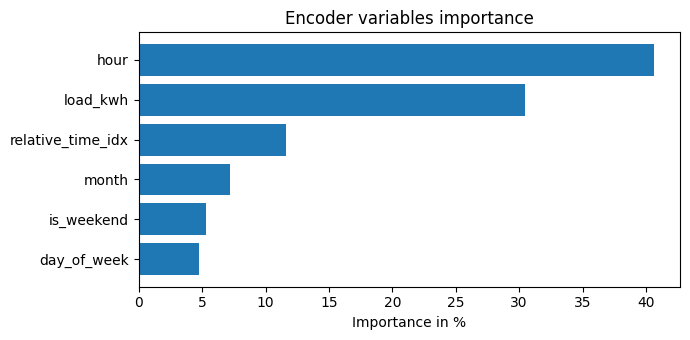

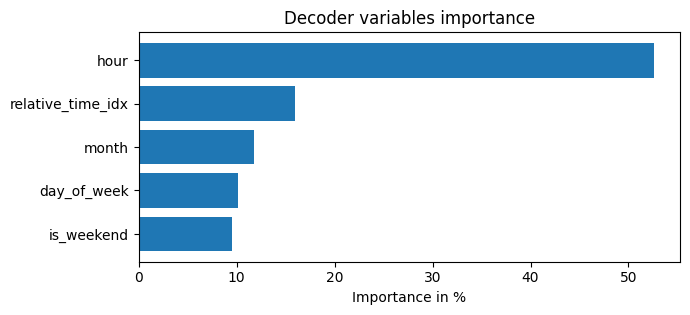

In [5]:
interpretation = model.interpret_output(raw_predictions.output, reduction="sum")
print("Interpretation components:", list(interpretation.keys()))

figs = model.plot_interpretation(interpretation)

Path("reports/figures").mkdir(parents=True, exist_ok=True)
for name, fig in figs.items():
    out_path = f"reports/figures/tft_interpretation_{name}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")

plt.show()

### Reading these plots

- **attention**: attention weight by relative time step in the lookback
  window (0 = most recent hour, -167 = 168 hours ago). Look for peaks at
  -24, -48, -168 -- these would indicate the model has learned to focus on
  the same hour on previous days/the previous week, mirroring the strong
  weekly seasonality that made seasonal-naive such a tough baseline
  earlier in this project.
- **encoder_variables** / **decoder_variables**: relative importance the
  model assigns to each input feature in the lookback window vs. the
  forecast window respectively. Compare against which lag features
  mattered most in the LightGBM baseline (`lag_168`, `lag_24`, etc.) --
  if TFT's attention independently converges on similar time offsets,
  that's a good cross-model consistency check.
- **static_variables**: how much the model leans on client identity
  itself vs. the time-varying signals.

## Single-sample deep dive

The aggregate view above averages across many clients and windows. This
section looks at one specific forecast in detail: the predicted quantile
fan chart alongside the attention weights that produced it, for one
concrete client and time window.

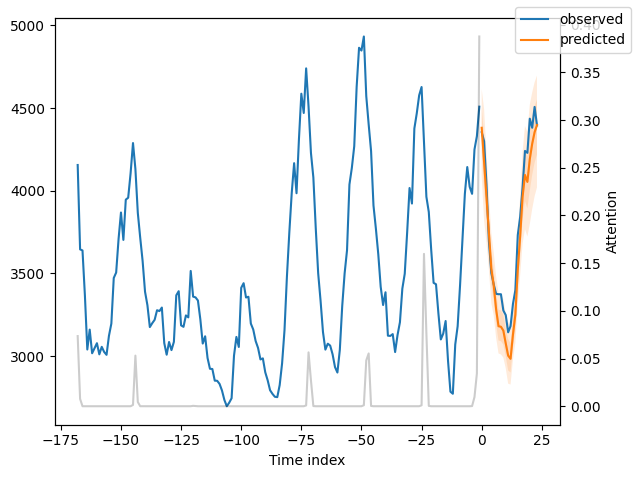

In [6]:
SAMPLE_IDX = 0  # change this to inspect different samples

fig = model.plot_prediction(
    raw_predictions.x, raw_predictions.output, idx=SAMPLE_IDX, plot_attention=True
)
fig.savefig(f"reports/figures/tft_sample_prediction_{SAMPLE_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()

Try a few different `SAMPLE_IDX` values (0 to {N_INTERPRET_SAMPLES - 1})
and look for patterns: does attention concentrate more tightly for
"regular" clients with strong weekly patterns, and more diffusely for
noisier/irregular ones? That contrast, if present, is worth a sentence or
two in the README -- it's a genuinely interesting, model-specific insight
that a point-estimate model like LightGBM or the LSTM can't surface at all.

## Summary

- Attention concentrates sharply at ~24-hour intervals within the lookback
  window, peaking at -24h (same hour, previous day) and the most recent
  hour (0). The model discovered daily periodicity independently, with no
  explicit seasonal feature -- directly corroborating the lag_24/lag_168
  features that were hand-engineered for the LightGBM baseline.

- `hour` is the single most important variable in both the encoder (~40%)
  and decoder (~53%) windows, even ahead of raw load values in the encoder
  (~30%) -- consistent with the attention pattern, since knowing the hour
  is what lets the model correctly align "yesterday at this same time."
  
- `client_id` dominates the static variables (~77%), confirming that client
  identity is the single most important signal for specialization -- this
  matches why adding client_id as a categorical feature fixed LightGBM's
  RMSE problem, and why the LSTM's client embedding was necessary. All
  three model families independently converged on the same conclusion.